In [2]:
import laspy
import numpy as np
from pathlib import Path
import CSF
import sys
from pathlib import Path
import laspy
import os

## Split large .las file into smaller tiles

CSF is used to classify terrain, separating ground points from the scene. This removes points unnecessary for tree detection and reduces the size of the resulting .las files. The .las file is then split into smaller tiles, each with its corresponding terrain file.

In [24]:

def segment_terrain(points_xyz):
    """Applies CSF and returns ground and non-ground indices."""
    csf = CSF.CSF()
    csf.params.bSloopSmooth = True
    csf.params.rigidness = 1
    csf.params.cloth_resolution = 0.75
    csf.params.time_step = 0.75
    csf.params.iterations = 500

    csf.setPointCloud(points_xyz)
    ground_indices = CSF.VecInt()
    non_ground_indices = CSF.VecInt()
    csf.do_filtering(ground_indices, non_ground_indices)
    return np.array(ground_indices, dtype=int), np.array(non_ground_indices, dtype=int)


In [25]:

def save_las(path, header, points_record):
    """Helper function to safely save LAS files."""
    new_las = laspy.LasData(header)
    new_las.points = points_record
    new_las.write(path)


In [ ]:
import laspy
import numpy as np
from pathlib import Path

def batch_process_complete_sequential(input_folder, output_root, tile_size=20):
    # Set up folder structure
    path_input   = Path(input_folder)
    path_trees   = Path(output_root) / "trees"
    path_terrain = Path(output_root) / "terrain"

    path_trees.mkdir(parents=True, exist_ok=True)
    path_terrain.mkdir(parents=True, exist_ok=True)

    global_tile_id = 0
    las_files = list(path_input.glob("*.las"))

    print(f"Starting full process for {len(las_files)} files.")

    for las_path in las_files:
        print(f"\nReading and segmenting: {las_path.name}")

        try:
            # Load the full file into RAM
            las = laspy.read(las_path)

            # Coordinates and bounds
            minX, minY = float(las.header.mins[0]), float(las.header.mins[1])

            # Compute tile grid
            xs = (las.x - minX) // tile_size
            ys = (las.y - minY) // tile_size
            unique_tiles = np.unique(np.vstack((xs, ys)).T, axis=0)

            # Process each tile
            for i, j in unique_tiles.astype(int):
                mask = (xs == i) & (ys == j)
                tile_data = las[mask]

                if len(tile_data) > 0:
                    # --- APPLY SEGMENT_TERRAIN ---
                    # Prepare points for CSF
                    points_xyz = np.ascontiguousarray(tile_data.xyz, dtype=np.float64)
                    ground_idx, tree_idx = segment_terrain(points_xyz)

                    fname = f"tile_{global_tile_id}.las"

                    # Save vegetation
                    if len(tree_idx) > 0:
                        save_las(path_trees   / fname, tile_data.header, tile_data.points[tree_idx])

                    # Save ground
                    if len(ground_idx) > 0:
                        save_las(path_terrain / fname, tile_data.header, tile_data.points[ground_idx])

                    global_tile_id += 1

            print(f"Done {las_path.name}. Tiles generated: {global_tile_id}")

        except Exception as e:
            print(f"Error processing {las_path.name}: {e}")

    print(f"PROCESS COMPLETE")
    print(f"Results in '{output_root}/trees' and '{output_root}/terrain'")

In [ ]:
LAS_FOLDER_PATH = "../../data/Santomera"
OUTPUT_FOLDER = "../../data/Santomera/tiles"

batch_process_complete_sequential(LAS_FOLDER_PATH, OUTPUT_FOLDER)

Iniciando proceso completo para 77 archivos.

Leyendo y segmentando: cloud0.las
Finalizado cloud0.las. Teselas generadas: 31

Leyendo y segmentando: cloud1.las
Finalizado cloud1.las. Teselas generadas: 62

Leyendo y segmentando: cloud10.las
Finalizado cloud10.las. Teselas generadas: 84

Leyendo y segmentando: cloud11.las
Finalizado cloud11.las. Teselas generadas: 121

Leyendo y segmentando: cloud12.las
Finalizado cloud12.las. Teselas generadas: 152

Leyendo y segmentando: cloud13.las
Finalizado cloud13.las. Teselas generadas: 229

Leyendo y segmentando: cloud14.las
Finalizado cloud14.las. Teselas generadas: 304

Leyendo y segmentando: cloud15_sub_block_0.las
Finalizado cloud15_sub_block_0.las. Teselas generadas: 370

Leyendo y segmentando: cloud15_sub_block_1.las
Finalizado cloud15_sub_block_1.las. Teselas generadas: 439

Leyendo y segmentando: cloud16.las
Finalizado cloud16.las. Teselas generadas: 509

Leyendo y segmentando: cloud17.las
Finalizado cloud17.las. Teselas generadas: 579



In [ ]:
import os
import shutil

LAS_FOLDER_PATH = "../../data/Santomera/tiles/trees"

# 400k points is the GPU memory limit

cont = 0
for filename in os.listdir(LAS_FOLDER_PATH):
    if filename.endswith(".las"):
        las_path = os.path.join(LAS_FOLDER_PATH, filename)
        las = laspy.read(las_path)
        if len(las.x) > 400000:
            print(f"{filename} exceeds limit ({len(las)} points). Splitting...")
            x_mid = (las.x.min() + las.x.max()) / 2
            left_mask  = las.x <  x_mid
            right_mask = las.x >= x_mid
            for side, suffix in [ (left_mask, "left"), (right_mask, "right") ]:
                side_points = las.points[side]
                if len(side_points) > 0:
                    new_las = laspy.LasData(las.header)
                    new_las.points = side_points
                    new_las.write(os.path.join(LAS_FOLDER_PATH, f"{filename[:-4]}_{suffix}.las"))
            os.remove(las_path)


tile_1071.las excede límite (517067 árboles). Dividiendo...
tile_1072.las excede límite (460456 árboles). Dividiendo...
tile_1098.las excede límite (565237 árboles). Dividiendo...
tile_1098_left.las excede límite (426706 árboles). Dividiendo...
tile_1179.las excede límite (419597 árboles). Dividiendo...
tile_1417.las excede límite (416375 árboles). Dividiendo...
tile_1455.las excede límite (453528 árboles). Dividiendo...
tile_2211.las excede límite (466253 árboles). Dividiendo...
tile_2800.las excede límite (483649 árboles). Dividiendo...
tile_2802.las excede límite (463953 árboles). Dividiendo...
tile_2805.las excede límite (879869 árboles). Dividiendo...
tile_2805_left.las excede límite (601514 árboles). Dividiendo...
tile_2806.las excede límite (874007 árboles). Dividiendo...
tile_2806_left.las excede límite (624164 árboles). Dividiendo...
tile_3014.las excede límite (438287 árboles). Dividiendo...
tile_3104.las excede límite (451063 árboles). Dividiendo...
tile_3142.las excede lími

Once the files have been split into smaller .las tiles, they are manually labelled in CloudCompare for subsequent model training.

Not all .las files were labelled — a representative subset was selected. This reduces the manual labelling effort while still providing enough data to train an effective tree-detection model.

## Split train/val/test: 70% train, 15% val, 15% test.

In [6]:
import numpy as np
import shutil

LABELED_LAS_FOLDER_PATH = "../../data/Santomera/tiles/trees/labeled/"

random_state = 42
np.random.seed(random_state)

train_pct, val_pct, test_pct = 0.7, 0.15, 0.15
las_files = [f for f in os.listdir(LABELED_LAS_FOLDER_PATH) if f.endswith(".las")]
num_trees = 380  # This number is obtained further down in the notebook
trees_train = int(num_trees * train_pct)
trees_val   = int(num_trees * val_pct)
trees_test  = num_trees - trees_train - trees_val

trees_train_assigned = 0
trees_val_assigned   = 0
trees_test_assigned  = 0

# Create destination folders
os.makedirs("../../data/Santomera/tree_assets/train/", exist_ok=True)
os.makedirs("../../data/Santomera/tree_assets/val/",   exist_ok=True)
os.makedirs("../../data/Santomera/tree_assets/test/",  exist_ok=True)

np.random.shuffle(las_files)

for random_file in las_files:
    las_path = os.path.join(LABELED_LAS_FOLDER_PATH, random_file)
    las = laspy.read(las_path)
    num_trees_in_file = len(np.unique(las.classification)) - 3  # Subtract classes 0,1,2
    if num_trees_in_file <= trees_train:
        shutil.copy(las_path, os.path.join("../../data/Santomera/tree_assets/train/", random_file))
        trees_train -= num_trees_in_file
        trees_train_assigned += num_trees_in_file
    elif num_trees_in_file <= trees_test:
        shutil.copy(las_path, os.path.join("../../data/Santomera/tree_assets/test/", random_file))
        trees_test -= num_trees_in_file
        trees_test_assigned += num_trees_in_file
    else:
        shutil.copy(las_path, os.path.join("../../data/Santomera/tree_assets/val/", random_file))
        trees_val -= num_trees_in_file
        trees_val_assigned += num_trees_in_file
print(f"Assigned to Train: {trees_train_assigned} trees ({trees_train_assigned/num_trees*100:.2f}%)"
      f"\nAssigned to Val:   {trees_val_assigned} trees ({trees_val_assigned/num_trees*100:.2f}%)"
      f"\nAssigned to Test:  {trees_test_assigned} trees ({trees_test_assigned/num_trees*100:.2f}%)")

Asignados a Train: 266 árboles (70.00%)
Asignados a Val: 55 árboles (14.47%)
Asignados a Test: 54 árboles (14.21%)


In [7]:
num_files_train = len(os.listdir("../../data/Santomera/tree_assets/train/"))
num_files_val = len(os.listdir("../../data/Santomera/tree_assets/val/"))
num_files_test = len(os.listdir("../../data/Santomera/tree_assets/test/"))

print(f"Archivos en Train: {num_files_train}"
      f"\nArchivos en Val: {num_files_val}"
        f"\nArchivos en Test: {num_files_test}")

Archivos en Train: 22
Archivos en Val: 4
Archivos en Test: 6


## Generate .npy files for DL model training

In [5]:
# # Add the project root to sys.path
import sys
from pathlib import Path
import os

root = Path("../..").resolve()
sys.path.append(str(root))

from scripts.utilsLAS import convert_las_to_assets

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [8]:
LABELED_LAS_FOLDER_PATH = "../../data/Santomera/tree_assets/"
folders = ["train", "val", "test"]

OUTPUT_ASSETS_FOLDER = "../../data/Santomera/tree_assets/"
os.makedirs(OUTPUT_ASSETS_FOLDER, exist_ok=True)
for folder in folders:
    os.makedirs(os.path.join(OUTPUT_ASSETS_FOLDER, folder), exist_ok=True)
    for filename in os.listdir(os.path.join(LABELED_LAS_FOLDER_PATH, folder)):
        if filename.endswith(".las"):
            las_path = os.path.join(LABELED_LAS_FOLDER_PATH, folder, filename)
            output_folder = os.path.join(OUTPUT_ASSETS_FOLDER, folder, Path(filename).stem)
            convert_las_to_assets(las_path, output_folder)
            os.remove(las_path)

 Assets creados en: ../../data/Santomera/tree_assets/train\tile_1457 (296136 puntos)
 Assets creados en: ../../data/Santomera/tree_assets/train\tile_1563 (320156 puntos)
 Assets creados en: ../../data/Santomera/tree_assets/train\tile_162 (299386 puntos)
 Assets creados en: ../../data/Santomera/tree_assets/train\tile_2209 (291643 puntos)
 Assets creados en: ../../data/Santomera/tree_assets/train\tile_2247 (307465 puntos)
 Assets creados en: ../../data/Santomera/tree_assets/train\tile_2248 (327931 puntos)
 Assets creados en: ../../data/Santomera/tree_assets/train\tile_238 (322922 puntos)
 Assets creados en: ../../data/Santomera/tree_assets/train\tile_2412 (294426 puntos)
 Assets creados en: ../../data/Santomera/tree_assets/train\tile_2484 (304270 puntos)
 Assets creados en: ../../data/Santomera/tree_assets/train\tile_3257_left (319372 puntos)
 Assets creados en: ../../data/Santomera/tree_assets/train\tile_3264 (291921 puntos)
 Assets creados en: ../../data/Santomera/tree_assets/train\til

# Generate .npy files for conference paper

In [2]:
# # Add the project root to sys.path
import sys
from pathlib import Path
import os

root = Path("../..").resolve()
sys.path.append(str(root))

from scripts.utilsLAS import convert_las_to_assets_conference

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
LABELED_LAS_FOLDER_PATH = "../../data/Santomera/tiles/trees/autolabeled/"


OUTPUT_ASSETS_FOLDER = "../../data/Santomera/tree_autolabeled_assets/"
os.makedirs(OUTPUT_ASSETS_FOLDER, exist_ok=True)
for filename in os.listdir(os.path.join(LABELED_LAS_FOLDER_PATH)):
    if filename.endswith(".las"):
        las_path = os.path.join(LABELED_LAS_FOLDER_PATH, filename)
        output_folder = os.path.join(OUTPUT_ASSETS_FOLDER, Path(filename).stem)
        convert_las_to_assets_conference(las_path, output_folder)

 Assets creados en: ../../data/Santomera/tree_autolabeled_assets/tile_1664 (225083 puntos)
 Assets creados en: ../../data/Santomera/tree_autolabeled_assets/tile_2157 (254524 puntos)
 Assets creados en: ../../data/Santomera/tree_autolabeled_assets/tile_2242 (257278 puntos)
 Assets creados en: ../../data/Santomera/tree_autolabeled_assets/tile_2253 (253600 puntos)
 Assets creados en: ../../data/Santomera/tree_autolabeled_assets/tile_2403 (242309 puntos)
 Assets creados en: ../../data/Santomera/tree_autolabeled_assets/tile_2482 (254937 puntos)
 Assets creados en: ../../data/Santomera/tree_autolabeled_assets/tile_2518 (213735 puntos)
 Assets creados en: ../../data/Santomera/tree_autolabeled_assets/tile_2521 (267349 puntos)
 Assets creados en: ../../data/Santomera/tree_autolabeled_assets/tile_2591 (272457 puntos)
 Assets creados en: ../../data/Santomera/tree_autolabeled_assets/tile_2596 (211766 puntos)
 Assets creados en: ../../data/Santomera/tree_autolabeled_assets/tile_2665 (242598 puntos)

## Generate assets for final AGB computation

In [6]:
LABELED_LAS_FOLDER_PATH = "../../data/Santomera/tiles/trees"
labeled_folders = ['labeled', 'unlabeled']

OUTPUT_ASSETS_FOLDER = "../../data/Santomera/tree_assets_final/"
os.makedirs(OUTPUT_ASSETS_FOLDER, exist_ok=True)

for folder in labeled_folders:
    for file in os.listdir(os.path.join(LABELED_LAS_FOLDER_PATH, folder)):
        if file.endswith(".las"):
            las_path = os.path.join(LABELED_LAS_FOLDER_PATH, folder, file)
            output_folder = os.path.join(OUTPUT_ASSETS_FOLDER, Path(file).stem)
            convert_las_to_assets(las_path, output_folder)

 Assets creados en: ../../data/Santomera/tree_assets_final/tile_1457 (296136 puntos)
 Assets creados en: ../../data/Santomera/tree_assets_final/tile_1563 (320156 puntos)
 Assets creados en: ../../data/Santomera/tree_assets_final/tile_162 (299386 puntos)
 Assets creados en: ../../data/Santomera/tree_assets_final/tile_2209 (291643 puntos)
 Assets creados en: ../../data/Santomera/tree_assets_final/tile_2247 (307465 puntos)
 Assets creados en: ../../data/Santomera/tree_assets_final/tile_2248 (327931 puntos)
 Assets creados en: ../../data/Santomera/tree_assets_final/tile_2260 (297637 puntos)
 Assets creados en: ../../data/Santomera/tree_assets_final/tile_2303 (306701 puntos)
 Assets creados en: ../../data/Santomera/tree_assets_final/tile_238 (322922 puntos)
 Assets creados en: ../../data/Santomera/tree_assets_final/tile_2412 (294426 puntos)
 Assets creados en: ../../data/Santomera/tree_assets_final/tile_2438 (309460 puntos)
 Assets creados en: ../../data/Santomera/tree_assets_final/tile_248

## Statistics of the labelled .las files

In [1]:
import laspy
import numpy as np
import os

las_folder_path = "../../data/Santomera/tiles/trees/labeled/"
num_trees = 0

for path in os.listdir(las_folder_path):
    if path.endswith(".las"):
        las_path = os.path.join(las_folder_path, path)
        las = laspy.read(las_path)
        num_trees += int(np.max(las.classification) - 3)
        print(f"{path}: {int(np.max(las.classification) - 3)} trees")

print(f"Total number of trees in folder: {num_trees}")
print(f"Number of tiles: {len(os.listdir(las_folder_path))}")

tile_1457.las: 14 árboles
tile_1563.las: 10 árboles
tile_162.las: 15 árboles
tile_2209.las: 28 árboles
tile_2247.las: 12 árboles
tile_2248.las: 12 árboles
tile_2260.las: 14 árboles
tile_2303.las: 14 árboles
tile_238.las: 3 árboles
tile_2412.las: 11 árboles
tile_2438.las: 9 árboles
tile_2484.las: 7 árboles
tile_3257_left.las: 12 árboles
tile_3264.las: 10 árboles
tile_3330.las: 21 árboles
tile_3337.las: 21 árboles
tile_3367_right.las: 13 árboles
tile_3378.las: 10 árboles
tile_3745.las: 10 árboles
tile_3747.las: 11 árboles
tile_3770.las: 4 árboles
tile_3771.las: 11 árboles
tile_3859.las: 11 árboles
tile_3952.las: 21 árboles
tile_3980.las: 9 árboles
tile_414_right.las: 13 árboles
tile_416.las: 20 árboles
tile_4185.las: 3 árboles
tile_4241.las: 2 árboles
tile_484.las: 14 árboles
tile_485.las: 11 árboles
tile_98.las: 4 árboles
Número total de árboles en la carpeta: 380
Número de parcelas: 32


Color medio (R, G, B) normalizado: (0.3749, 0.3847, 0.3206)


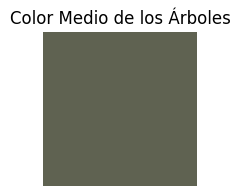

In [63]:
import laspy
import numpy as np
import os

las_folder_path = "../../data/Santomera/tiles/trees/labeled/"

total_red_sum   = 0.0
total_green_sum = 0.0
total_blue_sum  = 0.0
total_points    = 0

for path in os.listdir(las_folder_path):
    if path.endswith(".las"):
        las_path = os.path.join(las_folder_path, path)
        las = laspy.read(las_path)

        # Mask for tree points only
        mask = las.classification > 2

        if np.any(mask):
            # Accumulate channel totals
            total_red_sum   += np.sum(las.red[mask])
            total_green_sum += np.sum(las.green[mask])
            total_blue_sum  += np.sum(las.blue[mask])
            total_points    += np.sum(mask)

if total_points > 0:
    # Divide by total point count
    final_red   = total_red_sum   / total_points
    final_green = total_green_sum / total_points
    final_blue  = total_blue_sum  / total_points

    # Normalize to 0-1 (assuming 16-bit LAS standard)
    print(f"Mean colour (R, G, B) normalized: ({final_red/65535:.4f}, {final_green/65535:.4f}, {final_blue/65535:.4f})")
    import matplotlib.pyplot as plt

    color_rgb = (final_red/65535, final_green/65535, final_blue/65535)

    plt.figure(figsize=(2, 2))
    plt.imshow([[color_rgb]])
    plt.title("Mean Tree Colour")
    plt.axis('off')  # Hide axes
    plt.show()
else:
    print("No tree points found in the files.")


The colour is not green due to the many dry trees in the area.

In [ ]:
import laspy
import numpy as np
import os

las_folder_path = "../../data/Santomera/tiles/trees/labeled/"
pts_per_tree     = []
min_pts_per_tree = float('inf')
max_pts_per_tree = 0

for path in os.listdir(las_folder_path):
    if path.endswith(".las"):
        las_path = os.path.join(las_folder_path, path)
        las = laspy.read(las_path)
        for tree_id in range(3, int(np.max(las.classification)) + 1):
            mask = las.classification == tree_id
            num_pts = np.sum(mask)
            if num_pts > 0:
                pts_per_tree.append(num_pts)
                if num_pts < min_pts_per_tree:
                    min_pts_per_tree = num_pts
                if num_pts > max_pts_per_tree:
                    max_pts_per_tree = num_pts

print(f"Mean points per tree: {np.mean(pts_per_tree):.2f}")
print(f"Std dev of points per tree: {np.std(pts_per_tree):.2f}")
print(f"Min points per tree: {min_pts_per_tree}")
print(f"Max points per tree: {max_pts_per_tree}")

Media de número de puntos por árbol: 15741.46
Desviación estándar de puntos por árbol: 18440.34
Mínimo de puntos por árbol: 945
Máximo de puntos por árbol: 138313


In [3]:
import laspy
import numpy as np
import os

las_folder_path = "../../data/Santomera/tiles/trees/labeled/"

for path in os.listdir(las_folder_path):
    if path.endswith(".las"):
        las_path = os.path.join(las_folder_path, path)
        las = laspy.read(las_path)
        non_tree_pts = las.points[las.classification <= 2]
        print(f"{path}: Non-tree points: {len(non_tree_pts)}")
        tree_pts = las.points[las.classification > 2]
        print(f"{path}: Tree points: {len(tree_pts)}")


tile_1457.las: Número de puntos no-árbol: 25786
tile_1457.las: Número de puntos árbol: 270350
tile_1563.las: Número de puntos no-árbol: 237690
tile_1563.las: Número de puntos árbol: 82466
tile_162.las: Número de puntos no-árbol: 151656
tile_162.las: Número de puntos árbol: 147730
tile_2209.las: Número de puntos no-árbol: 74477
tile_2209.las: Número de puntos árbol: 217166
tile_2247.las: Número de puntos no-árbol: 26579
tile_2247.las: Número de puntos árbol: 280886
tile_2248.las: Número de puntos no-árbol: 24993
tile_2248.las: Número de puntos árbol: 302938
tile_2260.las: Número de puntos no-árbol: 37924
tile_2260.las: Número de puntos árbol: 259713
tile_2303.las: Número de puntos no-árbol: 149394
tile_2303.las: Número de puntos árbol: 157307
tile_238.las: Número de puntos no-árbol: 219330
tile_238.las: Número de puntos árbol: 103592
tile_2412.las: Número de puntos no-árbol: 61175
tile_2412.las: Número de puntos árbol: 233251
tile_2438.las: Número de puntos no-árbol: 237923
tile_2438.la

In [4]:
import laspy
import numpy as np
import os

las_folder_path = "../../data/Santomera/tiles/trees/labeled/"
non_tree_pts = []
tree_pts     = []
for path in os.listdir(las_folder_path):
    if path.endswith(".las"):
        las_path = os.path.join(las_folder_path, path)
        las = laspy.read(las_path)
        non_tree_pts_tile = las.points[las.classification <= 2]
        non_tree_pts.append(len(non_tree_pts_tile))
        tree_pts_tile = las.points[las.classification > 2]
        tree_pts.append(len(tree_pts_tile))

print(f"Mean non-tree points per tile: {np.mean(non_tree_pts):.2f}")
print(f"Mean tree points per tile: {np.mean(tree_pts):.2f}")

Media de puntos no árbol por parcela: 106205.78
Media de puntos árbol por parcela: 201195.56
